In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# Read data/par-to-par.json
with open("../data/par-to-par.json", "r") as f:
    data = json.load(f)

In [3]:
df = pd.read_csv("../data/par-to-par-og.csv")

for col in ["DATE_FROM", "DATE_TO"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [4]:
celex_to_advocate_general = {celex: info["meta"]["advocate_general"] for celex, info in data.items()}
celex_to_rapporteur = {celex: info["meta"]["rapporteur"] for celex, info in data.items()}
celex_to_applicant = {celex: info["meta"]["applicant"] for celex, info in data.items()}
celex_to_defendant = {celex: info["meta"]["defendant"] for celex, info in data.items()}
celex_to_lang = {celex: info["meta"]["authentic_language"] for celex, info in data.items()}


# Add ADVOCATE_TO, ADVOCATE_FROM etc. to df
df["ADVOCATE_FROM"] = df["CELEX_FROM"].apply(lambda x: celex_to_advocate_general.get(x))
df["ADVOCATE_TO"] = df["CELEX_TO"].apply(lambda x: celex_to_advocate_general.get(x))
df["RAPPORT_FROM"] = df["CELEX_FROM"].apply(lambda x: celex_to_rapporteur.get(x))
df["RAPPORT_TO"] = df["CELEX_TO"].apply(lambda x: celex_to_rapporteur.get(x))
df["APPLICANT_FROM"] = df["CELEX_FROM"].apply(lambda x: celex_to_applicant.get(x))
df["APPLICANT_TO"] = df["CELEX_TO"].apply(lambda x: celex_to_applicant.get(x))
df["DEFENDANT_FROM"] = df["CELEX_FROM"].apply(lambda x: celex_to_defendant.get(x))
df["DEFENDANT_TO"] = df["CELEX_TO"].apply(lambda x: celex_to_defendant.get(x))
df["LANG_FROM"] = df["CELEX_FROM"].apply(lambda x: celex_to_lang.get(x))
df["LANG_TO"] = df["CELEX_TO"].apply(lambda x: celex_to_lang.get(x))

In [5]:
def normalize(value):
    """Turn values into sets for comparison (list, dict, str, None)."""
    if value is None:
        return set()
    if isinstance(value, list):
        return set(value)
    if isinstance(value, dict):
        return set(value.items())  # dict compared as key-value pairs
    return {value}  # single element

def role_stats(df, role):
    from_col = f"{role}_FROM"
    to_col = f"{role}_TO"
    
    total = 0
    overlap = 0
    identical = 0
    
    for f, t in zip(df[from_col], df[to_col]):
        f_set = normalize(f)
        t_set = normalize(t)
        if not f_set or not t_set:
            continue
        
        total += 1
        if f_set & t_set:
            overlap += 1
        if f_set == t_set:
            identical += 1
    
    return {
        "total": total,
        "overlap": overlap,
        "identical": identical,
        "overlap_rate": overlap / total if total else None,
        "identical_rate": identical / total if total else None,
    }

# Apply to all roles
roles = ["ADVOCATE", "RAPPORT", "APPLICANT", "DEFENDANT", "LANG"]
stats = {role: role_stats(df, role) for role in roles}

for role, stat in stats.items():
    print(role)
    for key, value in stat.items():
        print(f"{key}: {value}")
    print("\n" + "="*100 + "\n")


ADVOCATE
total: 106463
overlap: 12721
identical: 12706
overlap_rate: 0.11948752148633798
identical_rate: 0.11934662746681945


RAPPORT
total: 110154
overlap: 17907
identical: 17907
overlap_rate: 0.16256332044228988
identical_rate: 0.16256332044228988


APPLICANT
total: 45358
overlap: 31775
identical: 31364
overlap_rate: 0.7005379425900613
identical_rate: 0.6914766965033732


DEFENDANT
total: 46532
overlap: 27051
identical: 25250
overlap_rate: 0.5813418722599502
identical_rate: 0.5426373248517149


LANG
total: 110179
overlap: 28328
identical: 26571
overlap_rate: 0.2571088864484158
identical_rate: 0.24116210893182913




In [6]:
# Analyze which languages cite which
from collections import defaultdict
import seaborn as sns

def normalize_lang(value):
    """Extract language code(s) from various formats."""
    if value is None:
        return []
    if isinstance(value, list):
        return [str(lang).strip() for lang in value if lang]
    if isinstance(value, str):
        return [value.strip()]
    return []

# Build citation matrix
citation_matrix = defaultdict(lambda: defaultdict(int))
citation_details = []

for idx, row in df.iterrows():
    lang_from_list = normalize_lang(row["LANG_FROM"])
    lang_to_list = normalize_lang(row["LANG_TO"])
    
    if not lang_from_list or not lang_to_list:
        continue
    
    # Handle all combinations (if multiple languages)
    for lang_from in lang_from_list:
        for lang_to in lang_to_list:
            citation_matrix[lang_from][lang_to] += 1
            citation_details.append({
                "from": lang_from,
                "to": lang_to,
                "celex_from": row["CELEX_FROM"],
                "celex_to": row["CELEX_TO"]
            })

# Convert to DataFrame for easier analysis
langs_from = sorted(set([d["from"] for d in citation_details]))
langs_to = sorted(set([d["to"] for d in citation_details]))
all_langs = sorted(set(langs_from + langs_to))

matrix_data = []
for lang_from in all_langs:
    row = []
    for lang_to in all_langs:
        row.append(citation_matrix[lang_from][lang_to])
    matrix_data.append(row)

citation_df = pd.DataFrame(matrix_data, index=all_langs, columns=all_langs)

print("Language Citation Matrix (absolute counts):")
print(citation_df)
print("\n" + "="*100 + "\n")


Language Citation Matrix (absolute counts):
     BUL  CES  DAN    DEU  ELL   ENG  EST  FIN   FRA  GLE  ...  LIT  MLT  \
BUL  198   13   39    353   51   230    2   23   235    0  ...   28    0   
CES    5   10   32    259   21   152    1    9   118    0  ...   19    0   
DAN   16    5  214    635   33   313    9   23   328    0  ...    3    0   
DEU  139   64  645  10033  472  4018   39  369  3683    0  ...   80    7   
ELL   10   11   99    631  426   329    0   57   611    0  ...    3    2   
ENG   68   53  430   3687  275  5246   38  242  2766    0  ...   22    7   
EST    4   10    4    101    5    46   13    4    50    0  ...    0    0   
FIN   11   15   54    451   36   264    0   79   233    0  ...    3    0   
FRA   69   29  285   3278  347  2122    6  202  4226    0  ...   27   24   
GLE    0    0    1      2    0     0    0    0     1    0  ...    0    0   
HRV    2    0    5     41    1     5    0    3     5    0  ...    0    0   
HUN   98   26   57    554   39   211    6   

In [7]:
# Calculate statistics
print("Language Citation Statistics:")
print("="*100)

# Total citations per source language
total_citations_from = citation_df.sum(axis=1)
print("\nTotal citations FROM each language:")
print(total_citations_from.sort_values(ascending=False))

# Total citations per target language
total_citations_to = citation_df.sum(axis=0)
print("\n\nTotal citations TO each language:")
print(total_citations_to.sort_values(ascending=False))

# Self-citations (same language)
self_citations = pd.Series({lang: citation_df.loc[lang, lang] for lang in all_langs})
print("\n\nSelf-citations (same language citing itself):")
print(self_citations.sort_values(ascending=False))

# Actual self-citation rate
self_citation_rate = (self_citations / total_citations_from).fillna(0)
print("\n\nActual self-citation rate (self-citations / total citations from):")
print(self_citation_rate.sort_values(ascending=False))

# Expected self-citation rate (baseline - what % of all citations go to each language)
total_all_citations = citation_df.sum().sum()
expected_self_citation_rate = (total_citations_to / total_all_citations).fillna(0)
print("\n\nExpected self-citation rate (baseline - % of all citations that go TO each language):")
print(expected_self_citation_rate.sort_values(ascending=False))

# Adjusted self-citation rate (actual vs expected)
# Ratio > 1 means more likely to self-cite than average, < 1 means less likely
adjusted_self_citation_rate = (self_citation_rate / expected_self_citation_rate).fillna(0)
print("\n\nAdjusted self-citation rate (actual / expected):")
print("Values > 1.0 mean more likely to self-cite than average")
print("Values < 1.0 mean less likely to self-cite than average")
print(adjusted_self_citation_rate.sort_values(ascending=False))

# Difference (actual - expected)
self_citation_difference = (self_citation_rate - expected_self_citation_rate).fillna(0)
print("\n\nDifference in self-citation rate (actual - expected, in percentage points):")
print(self_citation_difference.sort_values(ascending=False) * 100)

print("\n" + "="*100 + "\n")


Language Citation Statistics:

Total citations FROM each language:
DEU    27341
ENG    17122
FRA    15485
NLD    11896
ITA    11327
SPA     7569
ELL     3400
POR     2722
POL     2650
HUN     2622
DAN     2355
BUL     1937
SWE     1813
FIN     1702
RON     1502
CES     1011
LAV      849
LIT      751
SLK      627
SLV      467
EST      321
HRV      124
MLT       56
GLE        9
dtype: int64


Total citations TO each language:
DEU    29087
FRA    18680
ENG    17894
NLD    14080
ITA    11555
SPA     6146
DAN     2882
ELL     2859
POR     2096
SWE     1853
FIN     1686
HUN     1459
POL     1375
BUL     1175
RON      764
CES      414
SLK      407
LAV      391
LIT      356
SLV      251
EST      169
MLT       54
HRV       25
GLE        0
dtype: int64


Self-citations (same language citing itself):
DEU    10033
ENG     5246
FRA     4226
ITA     2822
NLD     2509
SPA     1503
ELL      426
HUN      264
POR      256
POL      238
DAN      214
BUL      198
RON      162
FIN       79
SWE       73
LAV 

In [8]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Wilson score confidence interval for proportions
def wilson_score_interval(successes, trials, alpha=0.05):
    """
    Calculate Wilson score confidence interval for a proportion.
    Better than normal approximation, especially for small sample sizes.
    """
    if trials == 0:
        return 0, 0
    
    z = stats.norm.ppf(1 - alpha/2)
    p = successes / trials
    denominator = 1 + z**2 / trials
    center = (p + z**2 / (2 * trials)) / denominator
    margin = z * np.sqrt((p * (1 - p) / trials + z**2 / (4 * trials**2))) / denominator
    
    return max(0, center - margin), min(1, center + margin)

# Calculate all the statistics with CIs
stats_data = []

for lang in all_langs:
    # Basic counts
    self_cites = self_citations[lang]
    total_from = total_citations_from[lang]
    total_to = total_citations_to[lang]
    
    # Actual self-citation rate
    actual_rate = self_cites / total_from if total_from > 0 else 0
    
    # CI for actual self-citation rate (Wilson score)
    if total_from > 0:
        actual_ci_lower, actual_ci_upper = wilson_score_interval(self_cites, total_from)
    else:
        actual_ci_lower, actual_ci_upper = 0, 0
    
    # Expected self-citation rate
    expected_rate = total_to / total_all_citations if total_all_citations > 0 else 0
    
    # CI for expected rate (based on all citations, so narrower)
    # Using normal approximation since denominator is large
    if total_all_citations > 0:
        se_expected = np.sqrt(expected_rate * (1 - expected_rate) / total_all_citations)
        expected_ci_lower = max(0, expected_rate - 1.96 * se_expected)
        expected_ci_upper = min(1, expected_rate + 1.96 * se_expected)
    else:
        expected_ci_lower, expected_ci_upper = 0, 0
    
    # Adjusted self-citation rate (ratio)
    adjusted_rate = actual_rate / expected_rate if expected_rate > 0 else 0
    
    # CI for adjusted rate (using delta method approximation)
    if expected_rate > 0 and total_from > 0:
        # Approximate variance using delta method
        var_actual = actual_rate * (1 - actual_rate) / total_from
        var_expected = expected_rate * (1 - expected_rate) / total_all_citations
        
        # For ratio R = A/E, Var(R) ≈ (A/E)^2 * (Var(A)/A^2 + Var(E)/E^2)
        if actual_rate > 0:
            var_ratio = adjusted_rate**2 * (var_actual / actual_rate**2 + var_expected / expected_rate**2)
            se_ratio = np.sqrt(var_ratio)
            adjusted_ci_lower = max(0, adjusted_rate - 1.96 * se_ratio)
            adjusted_ci_upper = adjusted_rate + 1.96 * se_ratio
        else:
            adjusted_ci_lower, adjusted_ci_upper = 0, 1.96 * np.sqrt(var_expected) / expected_rate
    else:
        adjusted_ci_lower, adjusted_ci_upper = 0, 0
    
    # Difference
    difference = actual_rate - expected_rate
    
    # Check if significantly different from expected
    significant_high = actual_ci_lower > expected_rate
    significant_low = actual_ci_upper < expected_rate
    
    stats_data.append({
        'Language': lang,
        'Self_Citations': self_cites,
        'Total_From': total_from,
        'Total_To': total_to,
        'Actual_Rate': actual_rate,
        'Actual_CI_Lower': actual_ci_lower,
        'Actual_CI_Upper': actual_ci_upper,
        'Expected_Rate': expected_rate,
        'Expected_CI_Lower': expected_ci_lower,
        'Expected_CI_Upper': expected_ci_upper,
        'Adjusted_Rate': adjusted_rate,
        'Adjusted_CI_Lower': adjusted_ci_lower,
        'Adjusted_CI_Upper': adjusted_ci_upper,
        'Difference': difference,
        'Difference_pct': difference * 100,
        'Significant_High': significant_high,
        'Significant_Low': significant_low
    })

self_citation_stats = pd.DataFrame(stats_data).set_index('Language')

# Print updated statistics with CIs
print("\n\n" + "="*100)
print("SELF-CITATION STATISTICS WITH CONFIDENCE INTERVALS")
print("-" * 100)

print("\n\nAdjusted self-citation rate (Actual / Expected) with 95% CI:")
display_df = self_citation_stats.sort_values('Adjusted_Rate', ascending=False).copy()
display_df['Rate_with_CI'] = display_df.apply(
    lambda row: f"{row['Adjusted_Rate']:.2f} ({row['Adjusted_CI_Lower']:.2f}-{row['Adjusted_CI_Upper']:.2f})",
    axis=1
)
print(display_df[['Self_Citations', 'Total_From', 'Adjusted_Rate', 'Adjusted_CI_Lower', 'Adjusted_CI_Upper', 'Difference_pct']])

print("\n\nLanguages with significantly HIGHER self-citation than expected:")
sig_high = self_citation_stats[self_citation_stats['Significant_High']].sort_values('Adjusted_Rate', ascending=False)
if len(sig_high) > 0:
    for lang, row in sig_high.iterrows():
        print(f"  {lang}: {row['Adjusted_Rate']:.2f} (95% CI: {row['Adjusted_CI_Lower']:.2f}-{row['Adjusted_CI_Upper']:.2f}), "
              f"Actual: {row['Actual_Rate']*100:.1f}%, Expected: {row['Expected_Rate']*100:.1f}%")
else:
    print("  None")

print("\n\nLanguages with significantly LOWER self-citation than expected:")
sig_low = self_citation_stats[self_citation_stats['Significant_Low']].sort_values('Adjusted_Rate')
if len(sig_low) > 0:
    for lang, row in sig_low.iterrows():
        print(f"  {lang}: {row['Adjusted_Rate']:.2f} (95% CI: {row['Adjusted_CI_Lower']:.2f}-{row['Adjusted_CI_Upper']:.2f}), "
              f"Actual: {row['Actual_Rate']*100:.1f}%, Expected: {row['Expected_Rate']*100:.1f}%")
else:
    print("  None")

print("\n\nSummary:")
print(f"Languages with significantly high self-citation: {self_citation_stats['Significant_High'].sum()}")
print(f"Languages with significantly low self-citation: {self_citation_stats['Significant_Low'].sum()}")
print(f"Languages not significantly different: {(~self_citation_stats['Significant_High'] & ~self_citation_stats['Significant_Low']).sum()}")

print("\n" + "="*100 + "\n")



SELF-CITATION STATISTICS WITH CONFIDENCE INTERVALS
----------------------------------------------------------------------------------------------------


Adjusted self-citation rate (Actual / Expected) with 95% CI:
          Self_Citations  Total_From  Adjusted_Rate  Adjusted_CI_Lower  \
Language                                                                 
EST                   13         321      27.715792          12.378206   
RON                  162        1502      16.327790          13.687380   
LAV                   42         849      14.633241          10.082005   
BUL                  198        1937      10.061747           8.615689   
SLK                   19         627       8.611272           4.707904   
HUN                  264        2622       7.981631           6.981975   
POL                  238        2650       7.554471           6.556475   
LIT                   14         751       6.056389           2.851406   
POR                  256        2722       

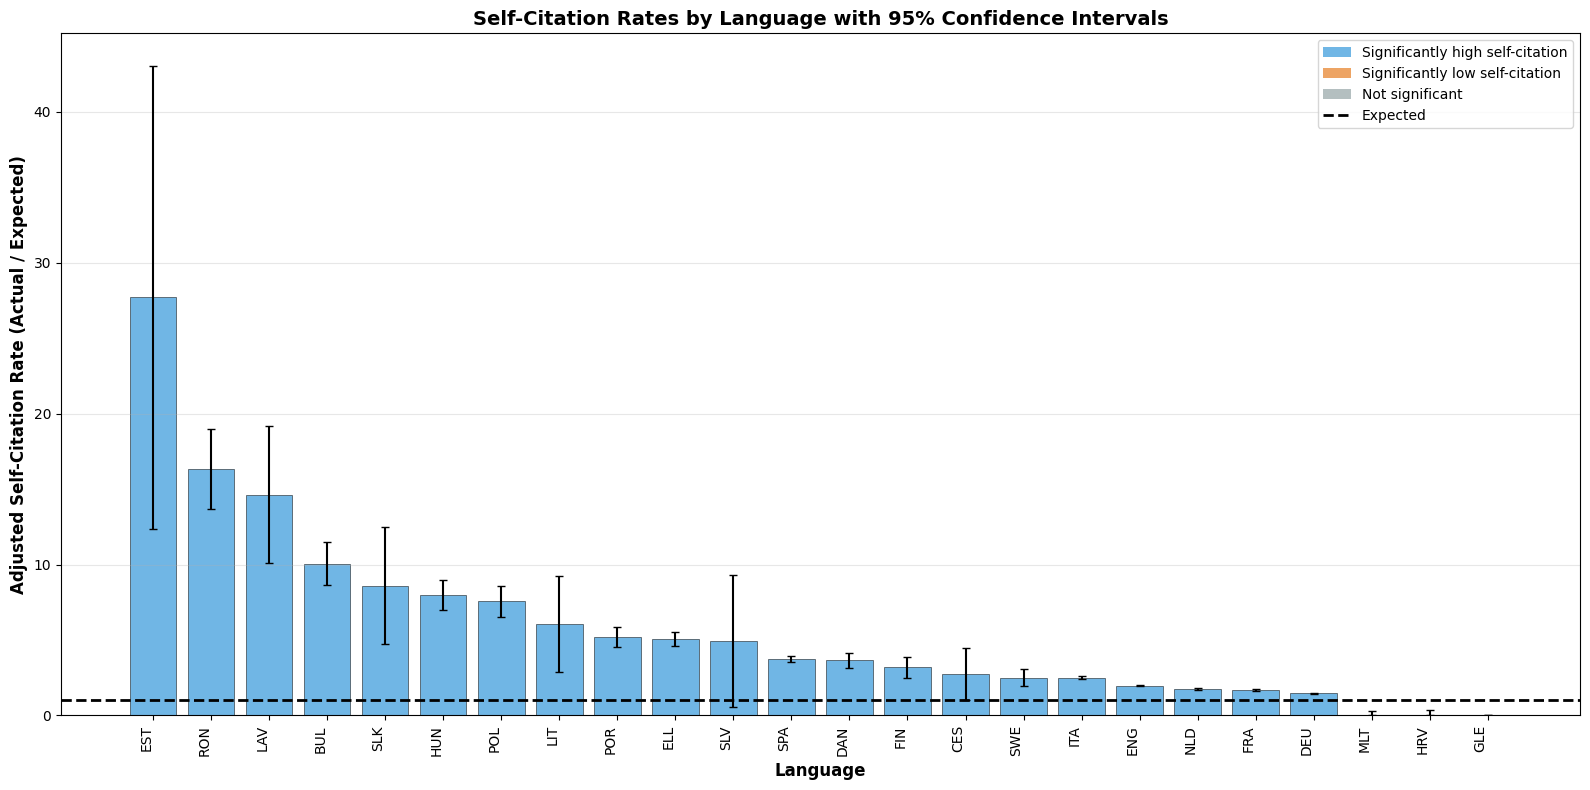

In [9]:
# Sort by adjusted rate for better visualization
stats_sorted = self_citation_stats.sort_values("Adjusted_Rate", ascending=False)

# Only show languages with at least some citations to avoid clutter
stats_filtered = stats_sorted[stats_sorted['Total_From'] > 0]

# Calculate error bar sizes
error_lower = stats_filtered["Adjusted_Rate"] - stats_filtered["Adjusted_CI_Lower"]
error_upper = stats_filtered["Adjusted_CI_Upper"] - stats_filtered["Adjusted_Rate"]

# Create color map: significant high (blue), significant low (orange), not significant (gray)
colors = []
for idx in stats_filtered.index:
    if stats_filtered.loc[idx, "Significant_High"]:
        colors.append('#3498db')  # blue - high self-citation
    elif stats_filtered.loc[idx, "Significant_Low"]:
        colors.append('#e67e22')  # orange - low self-citation
    else:
        colors.append('#95a5a6')  # gray - not significant

fig, ax = plt.subplots(figsize=(16, 8))

x_pos = np.arange(len(stats_filtered))
bars = ax.bar(x_pos, stats_filtered["Adjusted_Rate"], 
               yerr=[error_lower, error_upper],
               capsize=3, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add horizontal line at 1.0 (expected)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Expected (Ratio = 1.0)')

ax.set_xlabel('Language', fontsize=12, fontweight='bold')
ax.set_ylabel('Adjusted Self-Citation Rate (Actual / Expected)', fontsize=12, fontweight='bold')
ax.set_title('Self-Citation Rates by Language with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(stats_filtered.index, rotation=90, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', alpha=0.7, label='Significantly high self-citation'),
    Patch(facecolor='#e67e22', alpha=0.7, label='Significantly low self-citation'),
    Patch(facecolor='#95a5a6', alpha=0.7, label='Not significant'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Expected')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('self_citation_rates_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Calculate proportions
prop_citations_from = total_citations_from / total_all_citations
prop_citations_to = total_citations_to / total_all_citations

# Count how many unique documents exist in each language
doc_counts_from = {}
doc_counts_to = {}
for lang in all_langs:
    docs_from = set()
    docs_to = set()
    for detail in citation_details:
        if detail["from"] == lang:
            docs_from.add(detail["celex_from"])
        if detail["to"] == lang:
            docs_to.add(detail["celex_to"])
    doc_counts_from[lang] = len(docs_from)
    doc_counts_to[lang] = len(docs_to)

doc_counts_from_series = pd.Series(doc_counts_from)
doc_counts_to_series = pd.Series(doc_counts_to)
total_docs_from = doc_counts_from_series.sum()
total_docs_to = doc_counts_to_series.sum()

# Expected citations based on document availability (FROM)
prop_docs_from = doc_counts_from_series / total_docs_from if total_docs_from > 0 else pd.Series(0, index=all_langs)
expected_citations_baseline2 = prop_docs_from * total_all_citations
citation_ratio_baseline2 = total_citations_to / expected_citations_baseline2

print("\n\n" + "="*100)
print("Expected citations based on DOCUMENT AVAILABILITY (FROM)")
print("(Assumes citations are random - languages cited proportionally to available documents)")
print("-" * 100)
print("\nDocument counts (unique CELEX IDs):")
print("\nDocuments FROM each language:")
print(doc_counts_from_series.sort_values(ascending=False))
print("\nDocuments TO each language:")
print(doc_counts_to_series.sort_values(ascending=False))

print("\n\nActual citations TO vs Expected (based on document availability FROM):")
comparison_df2 = pd.DataFrame({
    "Actual_TO": total_citations_to,
    "Docs_FROM": doc_counts_from_series,
    "Expected_TO": expected_citations_baseline2,
    "Ratio": citation_ratio_baseline2,
    "Difference": total_citations_to - expected_citations_baseline2,
    "Difference_%": ((total_citations_to / total_all_citations) - prop_docs_from) * 100
})
comparison_df2 = comparison_df2.sort_values("Ratio", ascending=False)
print(comparison_df2)
print("\n\nLanguages cited MORE than expected (Ratio > 1.0):")
print(comparison_df2[comparison_df2["Ratio"] > 1.0][["Ratio", "Difference", "Difference_%"]])
print("\n\nLanguages cited LESS than expected (Ratio < 1.0):")
print(comparison_df2[comparison_df2["Ratio"] < 1.0][["Ratio", "Difference", "Difference_%"]])

# Summary statistics
print("\n\n" + "="*100)
print("SUMMARY STATISTICS")
print("-" * 100)
print(f"\nLanguages with Ratio > 1.5 (cited 50%+ more than expected): {len(comparison_df2[comparison_df2['Ratio'] > 1.5])}")
print(f"Languages with Ratio < 0.5 (cited 50%+ less than expected): {len(comparison_df2[comparison_df2['Ratio'] < 0.5])}")
print(f"\nMost over-cited languages (Top 5 by Ratio - Baseline 1):")
print(comparison_df2.head(5)[["Ratio", "Difference_%"]])
print(f"\nMost under-cited languages (Bottom 5 by Ratio - Baseline 1):")
print(comparison_df2.tail(5)[["Ratio", "Difference_%"]])

print("\n" + "="*100 + "\n")




Expected citations based on DOCUMENT AVAILABILITY (FROM)
(Assumes citations are random - languages cited proportionally to available documents)
----------------------------------------------------------------------------------------------------

Document counts (unique CELEX IDs):

Documents FROM each language:
DEU    1995
FRA    1368
ENG    1085
NLD     895
ITA     864
SPA     534
ELL     298
POR     219
POL     177
DAN     161
SWE     146
HUN     134
FIN     129
BUL     104
RON      93
CES      73
LIT      62
LAV      57
SLK      38
EST      31
SLV      30
HRV       8
MLT       4
GLE       1
dtype: int64

Documents TO each language:
DEU    2191
FRA    1645
ENG    1118
NLD    1045
ITA     962
SPA     489
ELL     270
DAN     185
POR     183
POL     148
HUN     128
SWE     122
FIN     109
BUL      95
RON      77
CES      58
LAV      53
LIT      43
SLK      36
SLV      26
EST      21
HRV       7
MLT       4
GLE       0
dtype: int64


Actual citations TO vs Expected (based on document a

In [11]:
from scipy import stats
import numpy as np

# Add confidence intervals assuming Poisson distribution for citation counts
def poisson_ci(count, alpha=0.05):
    """Calculate confidence interval for Poisson count data"""
    if count == 0:
        lower = 0
        upper = stats.chi2.ppf(1 - alpha/2, 2*(count + 1)) / 2
    else:
        lower = stats.chi2.ppf(alpha/2, 2*count) / 2
        upper = stats.chi2.ppf(1 - alpha/2, 2*(count + 1)) / 2
    return lower, upper

# Calculate CIs for actual citations
ci_lower = []
ci_upper = []
ratio_ci_lower = []
ratio_ci_upper = []

for lang in comparison_df2.index:
    actual = comparison_df2.loc[lang, "Actual_TO"]
    expected = comparison_df2.loc[lang, "Expected_TO"]
    
    # CI for actual count
    lower, upper = poisson_ci(actual)
    ci_lower.append(lower)
    ci_upper.append(upper)
    
    # CI for ratio
    if expected > 0:
        ratio_ci_lower.append(lower / expected)
        ratio_ci_upper.append(upper / expected)
    else:
        ratio_ci_lower.append(np.nan)
        ratio_ci_upper.append(np.nan)

comparison_df2["CI_Lower"] = ci_lower
comparison_df2["CI_Upper"] = ci_upper
comparison_df2["Ratio_CI_Lower"] = ratio_ci_lower
comparison_df2["Ratio_CI_Upper"] = ratio_ci_upper


print("\n\nActual citations TO vs Expected (with 95% Confidence Intervals):")
comparison_df2_display = comparison_df2.copy()
comparison_df2_display["Ratio_with_CI"] = comparison_df2_display.apply(
    lambda row: f"{row['Ratio']:.2f} ({row['Ratio_CI_Lower']:.2f}-{row['Ratio_CI_Upper']:.2f})",
    axis=1
)
print(comparison_df2_display[["Actual_TO", "Expected_TO", "Ratio_with_CI", "Difference_%"]])

# Flag statistically significant differences
comparison_df2["Significant_High"] = comparison_df2["Ratio_CI_Lower"] > 1.0
comparison_df2["Significant_Low"] = comparison_df2["Ratio_CI_Upper"] < 1.0

print("\n\nStatistically significantly OVER-cited (95% CI excludes 1.0):")
print(comparison_df2[comparison_df2["Significant_High"]][["Ratio", "Ratio_CI_Lower", "Ratio_CI_Upper"]])

print("\n\nStatistically significantly UNDER-cited (95% CI excludes 1.0):")
print(comparison_df2[comparison_df2["Significant_Low"]][["Ratio", "Ratio_CI_Lower", "Ratio_CI_Upper"]])



Actual citations TO vs Expected (with 95% Confidence Intervals):
     Actual_TO   Expected_TO     Ratio_with_CI  Difference_%
DAN       2882   2189.153304  1.32 (1.27-1.37)      0.599048
ENG      17894  14752.989654  1.21 (1.20-1.23)      2.715774
NLD      14080  12169.516812  1.16 (1.14-1.18)      1.651838
DEU      29087  27126.464848  1.07 (1.06-1.08)      1.695114
FRA      18680  18601.004467  1.00 (0.99-1.02)      0.068301
MLT         54     54.388902  0.99 (0.75-1.30)     -0.000336
ITA      11555  11748.002822  0.98 (0.97-1.00)     -0.166874
FIN       1686   1754.042088  0.96 (0.92-1.01)     -0.058830
SWE       1853   1985.194921  0.93 (0.89-0.98)     -0.114298
SPA       6146   7260.918411  0.85 (0.83-0.87)     -0.963979
BUL       1175   1414.111451  0.83 (0.78-0.88)     -0.206740
HUN       1459   1822.028215  0.80 (0.76-0.84)     -0.313881
SLK        407    516.694569  0.79 (0.71-0.87)     -0.094844
ELL       2859   4051.973195  0.71 (0.68-0.73)     -1.031466
POR       2096   2

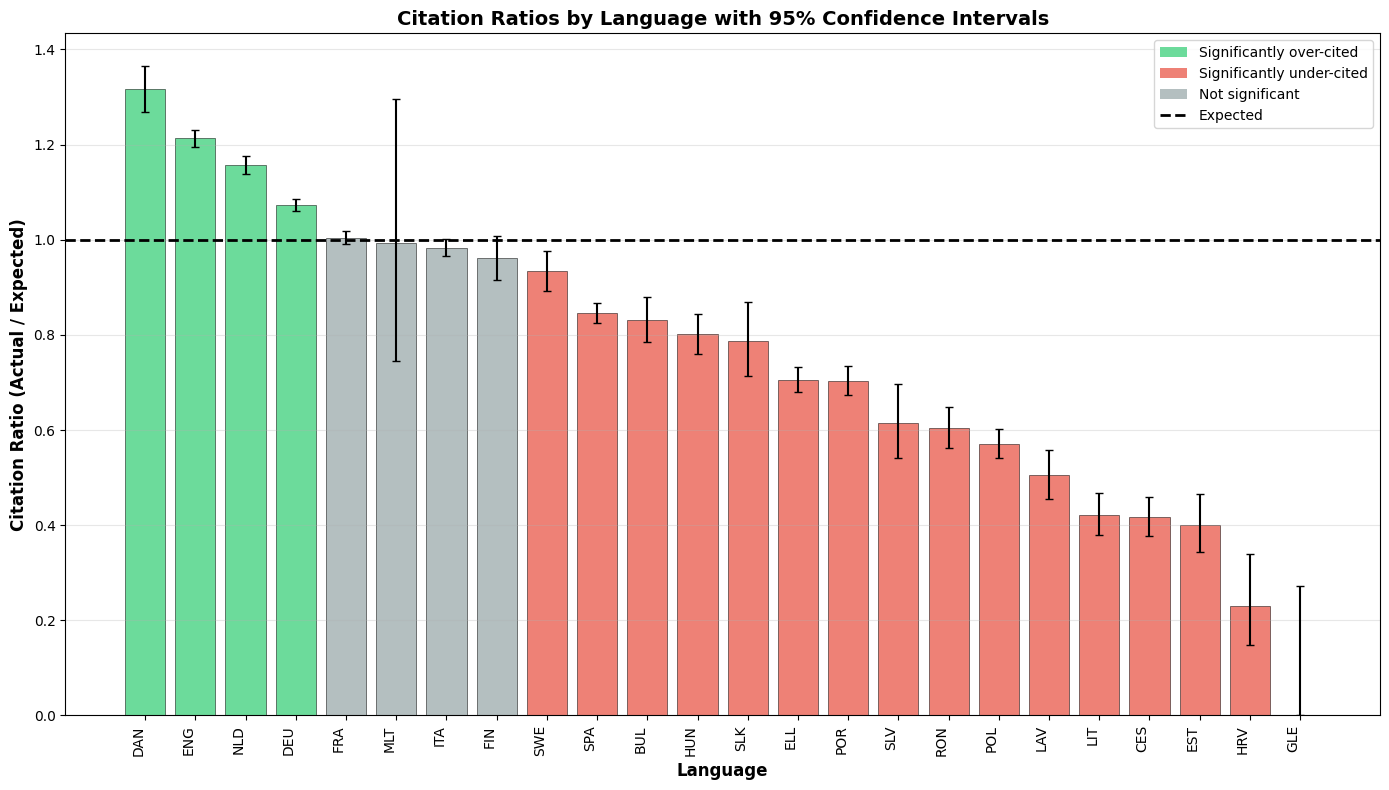

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by ratio for better visualization
comparison_df2_sorted = comparison_df2.sort_values("Ratio", ascending=False)

# Calculate error bar sizes (distance from ratio to CI bounds)
error_lower = comparison_df2_sorted["Ratio"] - comparison_df2_sorted["Ratio_CI_Lower"]
error_upper = comparison_df2_sorted["Ratio_CI_Upper"] - comparison_df2_sorted["Ratio"]

# Create color map: significant over (green), significant under (red), not significant (gray)
colors = []
for idx in comparison_df2_sorted.index:
    if comparison_df2_sorted.loc[idx, "Significant_High"]:
        colors.append('#2ecc71')  # green
    elif comparison_df2_sorted.loc[idx, "Significant_Low"]:
        colors.append('#e74c3c')  # red
    else:
        colors.append('#95a5a6')  # gray

fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(comparison_df2_sorted))
bars = ax.bar(x_pos, comparison_df2_sorted["Ratio"], 
               yerr=[error_lower, error_upper],
               capsize=3, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add horizontal line at 1.0 (expected)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Expected (Ratio = 1.0)')

ax.set_xlabel('Language', fontsize=12, fontweight='bold')
ax.set_ylabel('Citation Ratio (Actual / Expected)', fontsize=12, fontweight='bold')
ax.set_title('Citation Ratios by Language with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df2_sorted.index, rotation=90, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', alpha=0.7, label='Significantly over-cited'),
    Patch(facecolor='#e74c3c', alpha=0.7, label='Significantly under-cited'),
    Patch(facecolor='#95a5a6', alpha=0.7, label='Not significant'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Expected')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('citation_ratios_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Merge the two datasets
combined_stats = pd.merge(
    comparison_df2[['Actual_TO', 'Expected_TO', 'Ratio', 'Ratio_CI_Lower', 'Ratio_CI_Upper', 
                    'Docs_FROM', 'Significant_High', 'Significant_Low']],
    self_citation_stats[['Self_Citations', 'Total_From', 'Adjusted_Rate', 
                         'Adjusted_CI_Lower', 'Adjusted_CI_Upper', 'Actual_Rate']],
    left_index=True, right_index=True, how='inner'
)

# Rename columns for clarity
combined_stats = combined_stats.rename(columns={
    'Ratio': 'Citation_Ratio',
    'Ratio_CI_Lower': 'Citation_Ratio_CI_Lower',
    'Ratio_CI_Upper': 'Citation_Ratio_CI_Upper',
    'Significant_High': 'Over_Cited',
    'Significant_Low': 'Under_Cited',
    'Adjusted_Rate': 'Self_Citation_Ratio',
    'Adjusted_CI_Lower': 'Self_Citation_CI_Lower',
    'Adjusted_CI_Upper': 'Self_Citation_CI_Upper'
})

# Filter to languages with sufficient data (at least some citations)
combined_stats_filtered = combined_stats[
    (combined_stats['Total_From'] >= 5) & (combined_stats['Actual_TO'] >= 5)
].copy()

# Calculate correlation
correlation = combined_stats_filtered[['Citation_Ratio', 'Self_Citation_Ratio']].corr()
pearson_r, pearson_p = stats.pearsonr(
    combined_stats_filtered['Citation_Ratio'], 
    combined_stats_filtered['Self_Citation_Ratio']
)
spearman_r, spearman_p = stats.spearmanr(
    combined_stats_filtered['Citation_Ratio'], 
    combined_stats_filtered['Self_Citation_Ratio']
)

print("\n" + "="*100)
print("RELATIONSHIP BETWEEN CITATION REPRESENTATION AND SELF-CITATION TENDENCY")
print("-" * 100)
print(f"\nPearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman correlation: rho = {spearman_r:.3f}, p = {spearman_p:.4f}")


RELATIONSHIP BETWEEN CITATION REPRESENTATION AND SELF-CITATION TENDENCY
----------------------------------------------------------------------------------------------------

Pearson correlation: r = -0.447, p = 0.0325
Spearman correlation: rho = -0.522, p = 0.0106
